In [1]:
import os
os.environ["CL_VERBOSE"]="0"

In [1]:
from complex_langevin.simulation.state import SimState
from complex_langevin.simulation.evolution import SimEvol
from complex_langevin.models.zero_d_scalar_phi4 import SimModel
from complex_langevin.models.zero_d_scalar_phi4_gaussian_mod import ZeroDScalarPhi4GaussianMod
from complex_langevin.simulation.runner import SimRunner
from complex_langevin.observables.observables import SimObs
import torch
import numpy as np
from tqdm import tqdm

def set_sim(target_blocks=50, 
            auto_corr=1, 
            sigma=1+1j, 
            lamb=2,
            n_seeds=int(5e3), 
            device="cpu", 
            dt_base=1e-2,
    ):
    
    state = SimState(n_seeds = n_seeds, device=device, dt_base = dt_base)
#     model = ZeroDScalarPhi4GaussianMod(sigma=sigma, lamb = lamb, massmod=1.35, pull=9.04 )
    model = SimModel(sigma=sigma, lamb = lamb)
    evol = SimEvol(state, model)
    runner = SimRunner(state, model, evol)
    moment1 = SimObs(state, model, runner, "moment_1", auto_corr=auto_corr, order=1, target_blocks=target_blocks)
    moment2 = SimObs(state, model, runner, "moment_2", auto_corr=auto_corr, order=2, target_blocks=target_blocks)
    
    return state, model, runner, [moment1, moment2]

In [2]:
# example bounds (choose empirically)
re_min, re_max = -5, 5
im_min, im_max = -5, 5

bins_re = 300
bins_im = 300

class PhiHistogram:
    def __init__(self, re_range, im_range, bins, device):
        self.re_min, self.re_max = re_range
        self.im_min, self.im_max = im_range
        self.bins_re, self.bins_im = bins
        self.device = device

        self.hist = torch.zeros(
            (self.bins_re, self.bins_im),
            dtype=torch.float64,
            device=device
        )

        self.count = 0

    def update(self, phi: torch.Tensor):
        """
        phi: complex tensor of shape (n_seeds,)
        """
        re = phi.real
        im = phi.imag

        mask = (
            (re >= self.re_min) & (re < self.re_max) &
            (im >= self.im_min) & (im < self.im_max)
        )
        re = re[mask]
        im = im[mask]

        if re.numel() == 0:
            return

        i = ((re - self.re_min) / (self.re_max - self.re_min) * self.bins_re).long()
        j = ((im - self.im_min) / (self.im_max - self.im_min) * self.bins_im).long()

        i = torch.clamp(i, 0, self.bins_re - 1)
        j = torch.clamp(j, 0, self.bins_im - 1)

        self.hist.index_put_((i, j), torch.ones_like(i, dtype=self.hist.dtype), accumulate=True)
        self.count += i.numel()

class DriftMagnitudeHistogram:
    def __init__(self, bins, r_min, r_max, device):
        self.bins = bins
        self.r_min = r_min
        self.r_max = r_max
        self.device = device

        self.hist = torch.zeros(bins, dtype=torch.float64, device=device)
        self.count = 0

    def update(self, drift: torch.Tensor):
        """
        drift: complex tensor, shape (n_seeds,)
        """
        r = torch.abs(drift)

        # keep only values inside range
        mask = (r >= self.r_min) & (r < self.r_max)
        r = r[mask]

        if r.numel() == 0:
            return

        # bin index
        idx = ((r - self.r_min) / (self.r_max - self.r_min) * self.bins).long()
        idx = torch.clamp(idx, 0, self.bins - 1)

        self.hist.index_put_(
            (idx,),
            torch.ones_like(idx, dtype=self.hist.dtype),
            accumulate=True
        )

        self.count += idx.numel()


In [3]:
from typing import List

In [4]:
drift_hist = PhiHistogram((re_min, re_max), (im_min, im_max), bins = (bins_re, bins_im), device="cpu")
drift_hist = DriftMagnitudeHistogram(
    bins=200,
    r_min=1e-6,
    r_max=1e2,
    device="cpu",
)

def run_sim(state: SimState, model: SimModel, runner: SimRunner, observables: List[SimObs], eq_time: float = 10):
    while state.langevin_time[state.alive].min() < eq_time:
        runner.step()
        print(state.langevin_time[state.alive].min(), end = "\r")
        
    runner.log("Thermalization done!")
    
    while not np.all([_obs.is_done for _obs in observables]):
        runner.step()
        # phihist.update(state.phi)
        drift_hist.update(state.drift[state.alive])
        for _obs in observables: _obs.observe()
        print(state.langevin_time[state.alive].min(), end = "\r")

    runner.log("Simulation done")
    for _obs in observables: _obs.finish()

    return state, model, runner, observables

In [5]:
sim_objects = set_sim(auto_corr=4, target_blocks=50, sigma = 1+1j, n_seeds=int(1e3))

1767102608.66611: [SimState] initialized
1767102608.66734: [scalar_phi4] initialized
1767102608.667398: [SimEvol] initialized
1767102608.667434: [SimRunner] initialized
1767102608.6674628: [SimObs] moment_1 initialized
1767102608.668521: [SimObs] moment_2 initialized


In [6]:
state, model, runner, observables = run_sim(*sim_objects)

1767102610.945717: [SimRunner] Thermalization done!
1767102618.6473851: [SimRunner] Simulation done


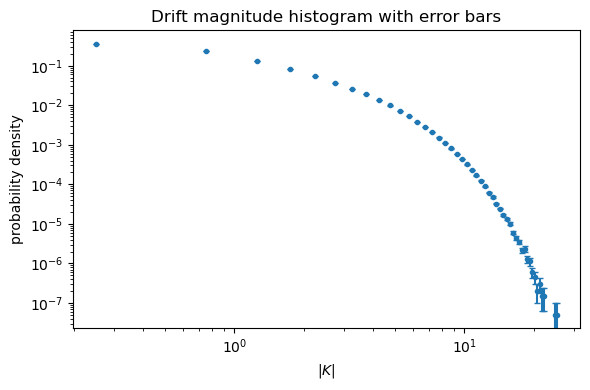

In [7]:
import numpy as np
import matplotlib.pyplot as plt

hist = drift_hist.hist.detach().cpu().numpy()
count = drift_hist.count

edges = np.linspace(drift_hist.r_min, drift_hist.r_max, drift_hist.bins + 1)
centers = 0.5 * (edges[:-1] + edges[1:])

# probability density
p = hist / count

# Poisson error bars
err = np.sqrt(hist) / count
mask = hist > 0

plt.figure(figsize=(6, 4))

plt.errorbar(
    centers[mask],
    p[mask],
    yerr=err[mask],
    fmt="o",
    markersize=3,
    capsize=2,
)

plt.xscale("log")
plt.yscale("log")
plt.xlabel(r"$|K|$")
plt.ylabel("probability density")
plt.title("Drift magnitude histogram with error bars")

plt.tight_layout()
plt.show()

In [8]:
state.alive_count

tensor(1000)

In [11]:
3*sim_objects[1].sigma.real**2 > sim_objects[1].sigma.imag**2

True

In [10]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

In [11]:
def jackknife_mean_and_cov(block_means: torch.Tensor):
    """
    block_means: complex tensor of shape (n_blocks, n_seeds)

    Returns
    -------
    mean : complex scalar
    Cov_mean : (2,2) real tensor (covariance of the mean)
    """
    # per-seed means (replicas)
    seed_means = block_means.mean(dim=0)   # (n_seeds,)
    n = seed_means.numel()

    # real / imag parts
    x = seed_means.real
    y = seed_means.imag

    # full mean
    mx = x.mean()
    my = y.mean()
    mean = mx + 1j * my

    # jackknife samples
    jkx = (x.sum() - x) / (n - 1)
    jky = (y.sum() - y) / (n - 1)

    # jackknife covariance of the mean
    var_x  = (n - 1) * ((jkx - mx) ** 2).mean()
    var_y  = (n - 1) * ((jky - my) ** 2).mean()
    cov_xy = (n - 1) * ((jkx - mx) * (jky - my)).mean()

    Cov_mean = torch.stack([
        torch.stack([var_x,  cov_xy]),
        torch.stack([cov_xy, var_y ]),
    ])

    return mean, Cov_mean


import torch

def jackknife_mean_and_cov(block_means: torch.Tensor):
    """
    NaN-aware jackknife estimator for complex observables.

    Parameters
    ----------
    block_means : complex tensor, shape (n_blocks, n_seeds)
        May contain NaNs for dead trajectories.

    Returns
    -------
    mean : complex scalar
        Jackknife mean.
    Cov_mean : (2,2) real tensor
        Covariance matrix of the mean (Re/Im).
    """

    # --- split real / imag ---
    x = block_means.real
    y = block_means.imag

    # --- per-seed means, ignoring NaNs ---
    mean_x_seed = torch.nanmean(x, dim=0)
    mean_y_seed = torch.nanmean(y, dim=0)

    # valid seeds = at least one non-NaN block
    valid = torch.isfinite(mean_x_seed) & torch.isfinite(mean_y_seed)

    mean_x_seed = mean_x_seed[valid]
    mean_y_seed = mean_y_seed[valid]

    n = mean_x_seed.numel()
    if n < 2:
        raise ValueError("Need at least 2 surviving seeds for jackknife")

    # --- full mean ---
    mx = mean_x_seed.mean()
    my = mean_y_seed.mean()
    mean = mx + 1j * my

    # --- jackknife leave-one-seed-out ---
    sum_x = mean_x_seed.sum()
    sum_y = mean_y_seed.sum()

    jkx = (sum_x - mean_x_seed) / (n - 1)
    jky = (sum_y - mean_y_seed) / (n - 1)

    # --- jackknife covariance of the mean ---
    var_x  = (n - 1) * ((jkx - mx) ** 2).mean()
    var_y  = (n - 1) * ((jky - my) ** 2).mean()
    cov_xy = (n - 1) * ((jkx - mx) * (jky - my)).mean()

    Cov_mean = torch.stack([
        torch.stack([var_x,  cov_xy]),
        torch.stack([cov_xy, var_y ]),
    ])

    return mean, Cov_mean




In [42]:
def plot_error_ellipse(
    mean: complex,
    Cov_mean: torch.Tensor,
    *,
    ax=None,
    n_sigma=1.0,
    edgecolor="C0",
    lw=2,
    label=None,
):
    """
    Plot an n-sigma error ellipse for a complex mean.
    """
    if ax is None:
        ax = plt.gca()

    C = Cov_mean.detach().cpu().numpy()
    mx, my = mean.real, mean.imag

    # eigen-decomposition
    evals, evecs = np.linalg.eigh(C)
    order = np.argsort(evals)[::-1]
    evals = evals[order]
    evecs = evecs[:, order]

    # ellipse geometry
    width, height = 2 * n_sigma * np.sqrt(evals)
    angle = np.degrees(np.arctan2(evecs[1, 0], evecs[0, 0]))

    ellipse = Ellipse(
        (mx, my),
        width=width,
        height=height,
        angle=angle,
        fill=False,
        edgecolor=edgecolor,
        lw=lw,
        label=label,
    )
    rx = 2.5 * np.sqrt(evals.max()).item()
    ry = 2.5 * np.sqrt(evals.min()).item()
    ax.set_xlim(mx - rx, mx + rx)
    ax.set_ylim(my - ry, my + ry)
    ax.add_patch(ellipse)
    ax.plot(mx, my, "o", color=edgecolor)
    ax.set_box_aspect(1)   # makes the plot square in screen space


    return ax


In [43]:
def plot_mean_and_ellipses(block_means: torch.Tensor, model: SimModel = None, order = 1):
    mean, Cov_mean = jackknife_mean_and_cov(block_means)

    fig, ax = plt.subplots(figsize=(6, 6))

    plot_error_ellipse(mean, Cov_mean, ax=ax, n_sigma=1.0, edgecolor="C1", label="1σ")
    plot_error_ellipse(mean, Cov_mean, ax=ax, n_sigma=2.0, edgecolor="C2", label="2σ")
    ax.scatter(model.momment(order).real, model.momment(order).imag)

    ax.set_xlabel("Re ⟨O⟩")
    ax.set_ylabel("Im ⟨O⟩")
    ax.legend()
    ax.set_title("Mean and jackknife error ellipses")

    # --- limits from covariance ---
    Cov = Cov_mean.detach().cpu().numpy()
    evals = np.linalg.eigvalsh(Cov)    
    rx = 2.5 * np.sqrt(evals.max()).item()
    ry = 2.5 * np.sqrt(evals.min()).item()

    mx, my = mean.real, mean.imag
    # ax.set_xlim(mx - rx, mx + rx)
    # ax.set_ylim(my - ry, my + ry)
    print(model.momment(order).real, model.momment(order).imag)

    # ax.set_box_aspect(1)
    plt.tight_layout()
    plt.show()

    return mean, Cov_mean


In [44]:
def lag1_autocorr_per_seed(B):
    x0 = B[:-1, :]
    x1 = B[1:, :]
    x0 = x0 - x0.mean(dim=0, keepdim=True)
    x1 = x1 - x1.mean(dim=0, keepdim=True)
    num = (x0 * x1).sum(dim=0)
    den = torch.sqrt((x0*x0).sum(dim=0) * (x1*x1).sum(dim=0))
    return num / den


6.678533511342931e-17 -4.34018260033536e-18


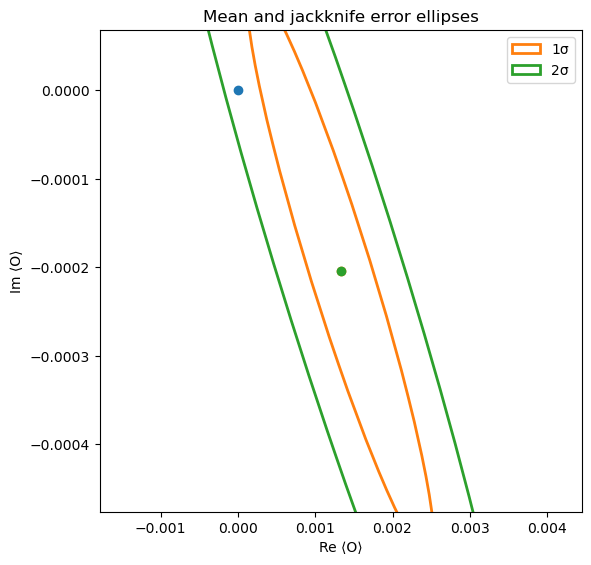

In [45]:
block_means = observables[0].rolling_accumulator.block_means  # (n_blocks, n_seeds)

block_means_survivors = block_means[:, state.alive]

mean, covm = plot_mean_and_ellipses(block_means_survivors,model=model, order = 1)

6.678533511342931e-17 -4.34018260033536e-18


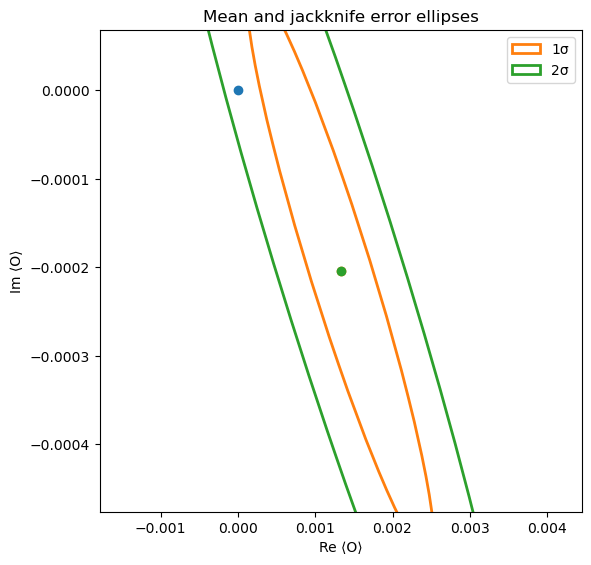

0.34869957903839943 -0.0889368289899673


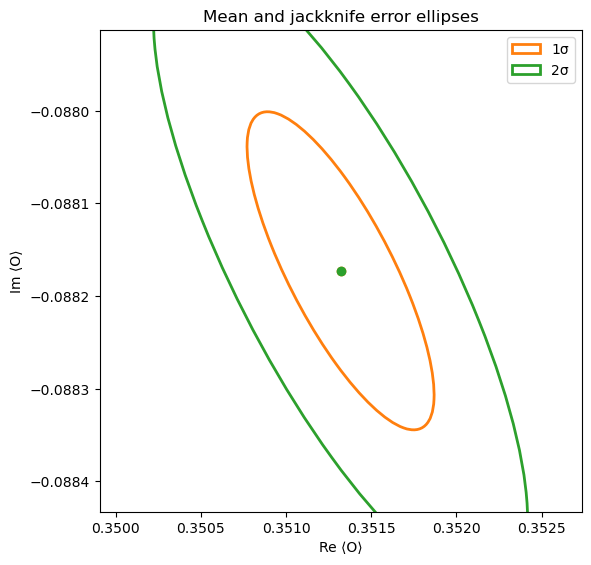

tensor(0.3513-0.0882j)


In [46]:
mean, covm = plot_mean_and_ellipses(observables[0].rolling_accumulator.block_means, model = model, order = 1)
mean, covm = plot_mean_and_ellipses(observables[1].rolling_accumulator.block_means, model = model, order = 2)
# mean, covm = plot_mean_and_ellipses(observables[2].rolling_accumulator.block_means[:, state.alive], order = 3)
# mean, covm = plot_mean_and_ellipses(observables[3].rolling_accumulator.block_means[:, state.alive], order = 4)
# mean, covm = plot_mean_and_ellipses(observables[4].rolling_accumulator.block_means[:, state.alive], order = 5)
print(mean)

In [29]:
print(mean)

tensor(0.3513-0.0882j)


In [31]:
observables[1].order

2

median block mean correlation

In [39]:
np.logspace(np.log10(10), np.log10(80), 5)

array([10.        , 16.81792831, 28.28427125, 47.5682846 , 80.        ])

In [172]:
corr_per_target_per_autocorr = []
target_blocks_list = np.logspace(np.log10(10), np.log10(80), 5)
target_blocks_list = [10]

for target_blocks in target_blocks_list:
    target_blocks = int(target_blocks)
    rho_list = []
    auto_corr_list = np.logspace(np.log10(0.5), np.log10(5.0), 5)

    for auto_corr in auto_corr_list:
        state, model, runner, moment2 = run_sim(*set_sim(auto_corr=auto_corr, target_blocks=target_blocks))
        moment2 = moment2[0]
        rho1 = lag1_autocorr_per_seed(moment2.rolling_accumulator.block_means.real)
        rho_list.append(rho1.median().item())
        print(f"target_blocks: {target_blocks}, auto_corr: {auto_corr} DONE")
    corr_per_target_per_autocorr.append(rho_list)

target_blocks: 10, auto_corr: 0.5 DONE
target_blocks: 10, auto_corr: 0.8891397050194614 DONE
target_blocks: 10, auto_corr: 1.5811388300841898 DONE
target_blocks: 10, auto_corr: 2.8117066259517456 DONE
target_blocks: 10, auto_corr: 5.000000000000001 DONE


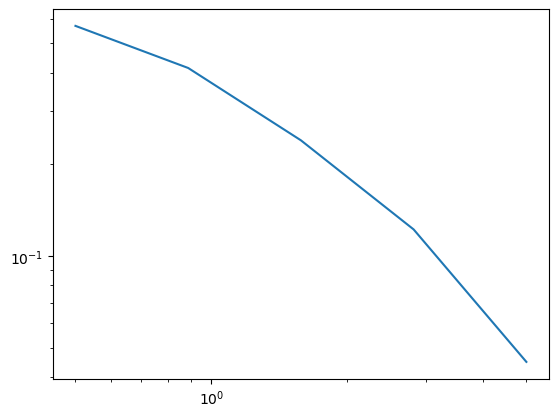

In [146]:
corr_per_target_per_autocorr = np.array(corr_per_target_per_autocorr)
for rho_list in corr_per_target_per_autocorr:
    plt.plot(auto_corr_list, np.abs(rho_list))
    plt.loglog()

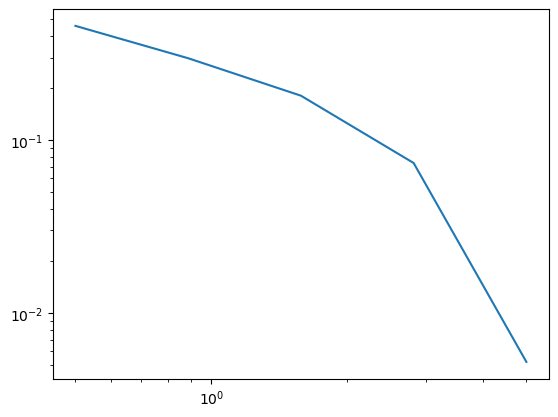

In [173]:
corr_per_target_per_autocorr = np.array(corr_per_target_per_autocorr)
for rho_list in corr_per_target_per_autocorr:
    plt.plot(auto_corr_list, np.abs(rho_list))
    plt.loglog()

In [39]:
x = moment2.rolling_accumulator.block_means[:, 6].real
rho1 = torch.corrcoef(torch.stack([x[:-1], x[1:]]))[0,1]
print(rho1.item())

0.4488515853881836


In [22]:
vals = moment2.rolling_accumulator.block_means.reshape(-1).real
print(vals.quantile(torch.tensor([0.5, 0.9, 0.99], device=vals.device)))
print(vals.max())

tensor([0.1871, 0.9399, 1.7983])
tensor(2.9942)


In [7]:
import torch

def cov2_complex_from_blocks(B: torch.Tensor):
    """
    B: complex tensor of shape (n_seeds, n_blocks) (or (n_blocks, n_seeds) – just flatten)
    Returns: mean (complex), Cov (2x2 real tensor), N (int)
    """
    z = B.reshape(-1)
    x = z.real.to(torch.float64)
    y = z.imag.to(torch.float64)

    N = x.numel()
    mx = x.mean()
    my = y.mean()

    # unbiased covariance
    dx = x - mx
    dy = y - my

    var_x  = (dx @ dx) / (N - 1)
    var_y  = (dy @ dy) / (N - 1)
    cov_xy = (dx @ dy) / (N - 1)

    Cov = torch.tensor([[var_x, cov_xy],
                        [cov_xy, var_y]], dtype=torch.float64)

    mean = (mx + 1j * my)
    return mean, Cov, N

mean, Cov, N = cov2_complex_from_blocks(moment2.rolling_accumulator.block_means.flatten())
Cov_mean = Cov / N

evals, evecs = torch.linalg.eigh(Cov_mean)  # evals >= 0
sigmas = torch.sqrt(evals)   
sigmas

tensor([0.0006, 0.0031], dtype=torch.float64)

In [8]:
data = moment2.rolling_accumulator.block_means.flatten()
print(f"{data.mean() - data.std()/np.sqrt(len(data))} {data.mean() + data.std()/np.sqrt(len(data))}")
print(model.momment(2))

(0.34846505522727966-0.09004762768745422j) (0.3547306954860687-0.09004762768745422j)
(0.34869957903839943-0.0889368289899673j)


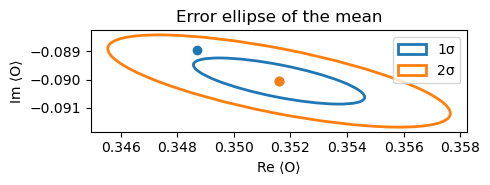

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse


def plot_error_ellipse(
    mean: complex,
    Cov_mean,
    *,
    ax=None,
    n_sigma=1.0,
    edgecolor="C0",
    facecolor="none",
    lw=2,
    label=None,
):
    """
    Plot an n-sigma error ellipse for a complex mean.

    Parameters
    ----------
    mean : complex
        Mean value (x + i y)
    Cov_mean : (2,2) tensor or ndarray
        Covariance of the mean
    n_sigma : float
        Confidence level (1=68%, 2=95%, ...)
    """
    if ax is None:
        ax = plt.gca()

    # convert to numpy
    C = Cov_mean.detach().cpu().numpy()
    mx, my = mean.real, mean.imag

    # eigen-decomposition
    evals, evecs = np.linalg.eigh(C)
    order = np.argsort(evals)[::-1]
    evals = evals[order]
    evecs = evecs[:, order]

    # semi-axis lengths
    width, height = 2 * n_sigma * np.sqrt(evals)

    # rotation angle (degrees)
    angle = np.degrees(np.arctan2(evecs[1, 0], evecs[0, 0]))

    ellipse = Ellipse(
        (mx, my),
        width=width,
        height=height,
        angle=angle,
        edgecolor=edgecolor,
        facecolor=facecolor,
        lw=lw,
        label=label,
    )

    ax.add_patch(ellipse)
    ax.plot(mx, my, marker="o", color=edgecolor)

    return ax
fig, ax = plt.subplots(figsize=(5, 5))

plot_error_ellipse(
    mean,
    Cov_mean,
    ax=ax,
    n_sigma=1.0,
    edgecolor="C0",
    label="1σ",
)

plot_error_ellipse(
    mean,
    Cov_mean,
    ax=ax,
    n_sigma=2.0,
    edgecolor="C1",
    label="2σ",
)
# ax.scatter(data.real, data.imag, s = 2)
ax.scatter(model.momment(2).real, model.momment(2).imag)
# ax.scatter(data.real.mean(), data.imag.mean(), color= "red")
ax.set_xlabel("Re ⟨O⟩")
ax.set_ylabel("Im ⟨O⟩")
ax.set_aspect("equal")
ax.legend()
ax.set_title("Error ellipse of the mean")
plt.tight_layout()
plt.show()

In [13]:
# rolling measurements
# find those seeds, that have passed dt_base since last observation

moment2.log("start observation")

mask = moment2.cold_rolling & moment2.daq_active
moment2.log(f"Last rolling obs: {moment2.last_rolling_meas}")
moment2.log(f"Langevin time: {state.langevin_time}")

# if there are any, observe them
if mask.any():
    moment2.log(f"rolling cold and active daq: {mask}")
    obs = moment2.measure_observable()

    # pass the new data to the rolling accumulator
    moment2.rolling_accumulator.update(obs, mask)

    # for those seedsobserved, write the time of observation
    moment2.last_rolling_meas[mask] = moment2.state.langevin_time[mask]

else: 
    moment2.log("no seeds are ready for rolling obs")

moment2.log("\n")

# reduce rolling observations
# find those seeds, that have passed auto_corr since last reduction
mask = (
    moment2.cold_block
    & moment2.daq_active
    & (moment2.rolling_accumulator.count > 0)
)     

# if there are any, reduce them
moment2.log(f"Last reduction: {moment2.last_block_flush}")
moment2.log(f"Langevin time: {state.langevin_time}")

if mask.any():
    moment2.log(f"block cold and active daq: {mask}")

    block_obs = moment2.rolling_accumulator.reduce(mask)
    idx = torch.nonzero(mask, as_tuple=True)[0]
    
    moment2.block_stack.append({
        "idx": idx.clone(),
        **{k: v.clone() for k, v in block_obs.items()}
    })

    moment2.rolling_accumulator.reset(mask)
    moment2.blocks_done[mask] += 1          # NEW
    moment2.last_block_flush[mask] = moment2.state.langevin_time[mask]
    moment2.log(f"reduced data to blocks: {mask} at times: {moment2.state.langevin_time[mask]}")

else: 
    moment2.log("no seeds are ready for reduction")

moment2.log("\n")


1766881825.572004: [SimObs] start observation
1766881825.578596: [SimObs] Last rolling obs: tensor([14.2506, 14.1944, 14.2684, 14.1644, 14.2653, 14.2577, 14.2540, 14.0736,
        14.2226, 14.1262, 14.2427, 14.1400, 14.2099, 14.2424, 14.1921, 14.1650,
        14.2360, 14.2537, 14.1772, 14.2338, 14.2686, 14.2614, 14.2631, 14.2666,
        14.2308, 14.2642, 14.1939, 14.2174, 14.2550, 14.2633, 14.2269, 14.2668,
        14.2024, 14.2518, 14.2398, 14.2536, 14.2681, 14.2402, 14.0926, 14.0776,
        14.2616, 14.2506, 14.2273, 14.2420, 14.1684, 14.1945, 14.2452, 14.2686,
        14.2687, 14.2590, 14.2401, 14.2677, 14.2050, 14.2089, 14.2216, 14.1897,
        14.2667, 14.2674, 14.2688, 14.2629, 14.2179, 14.2671, 14.2572, 14.2642,
        14.2440, 14.2686, 14.2151, 14.2690, 14.2673, 14.2344, 14.2607, 14.2234,
        14.2624, 14.2327, 14.1542, 14.2669, 14.2469, 14.2538, 14.2684, 14.2084,
        14.2689, 14.2443, 14.2405, 14.2589, 14.1678, 14.2533, 14.2264, 14.2677,
        14.1932, 14.2624, 14

AttributeError: 'RollingComplexAccumulator' object has no attribute 'count'

In [31]:
mask = torch.tensor([True, True], device = state.device)
moment2.count_rolling = torch.tensor([10, 20], device=state.device)
moment2.count_reduced = torch.tensor([1,1], device=state.device)

moment2.rolling_accumulator.sum_x = torch.ones(state.n_seeds , device=state.device) * 50
block_means = torch.zeros((20, 2), device = state.device) * torch.nan

valid = mask & (moment2.count_rolling > 0)
print(valid)

if valid.any():
    rows = torch.nonzero(valid, as_tuple=True)[0]
    nums = moment2.count_rolling[rows]
    # print(nums)

    mean_x = moment2.rolling_accumulator.sum_x[rows] / nums
    mean_y = moment2.rolling_accumulator.sum_y[rows] / nums
    cols = moment2.count_reduced[rows]-1   # 👈 block index per seed
    block_means[rows, cols] = mean_x
    # block_means_y[rows, cols] = mean_y

    # moment2.count_reduced[rows] += 1
block_means

tensor([True, True], device='cuda:0')


tensor([[5.0000,    nan],
        [2.5000,    nan],
        [   nan,    nan],
        [   nan,    nan],
        [   nan,    nan],
        [   nan,    nan],
        [   nan,    nan],
        [   nan,    nan],
        [   nan,    nan],
        [   nan,    nan],
        [   nan,    nan],
        [   nan,    nan],
        [   nan,    nan],
        [   nan,    nan],
        [   nan,    nan],
        [   nan,    nan],
        [   nan,    nan],
        [   nan,    nan],
        [   nan,    nan],
        [   nan,    nan]], device='cuda:0')

In [4]:
print("max count_reduced:", int(moment2.count_reduced.max().item()))
print("min count_reduced:", int(moment2.count_reduced.min().item()))
print("n_blocks:", block_means.shape[1])

max count_reduced: 2
min count_reduced: 2
n_blocks: 2


In [169]:
block_means = torch.zeros((20, 2), device = state.device) * torch.nan
mean_x = torch.tensor([1], dtype=block_means.dtype, device=state.device)
mask = torch.tensor([1])

block_means[mask] = mean_x
block_means

tensor([[nan, nan],
        [1., 1.],
        [nan, nan],
        [nan, nan],
        [nan, nan],
        [nan, nan],
        [nan, nan],
        [nan, nan],
        [nan, nan],
        [nan, nan],
        [nan, nan],
        [nan, nan],
        [nan, nan],
        [nan, nan],
        [nan, nan],
        [nan, nan],
        [nan, nan],
        [nan, nan],
        [nan, nan],
        [nan, nan]], device='cuda:0')

In [91]:
%%timeit
counts[0] += 1

21.7 μs ± 2.23 μs per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


In [ ]:
moment2.block_stack_new = torch.nan()

[{'idx': tensor([0], device='cuda:0'),
  'mean': tensor([0.2969+2.9600e-13j], device='cuda:0', dtype=torch.complex128),
  'var_x': tensor([0.0243], device='cuda:0', dtype=torch.float64),
  'var_y': tensor([1.0927e-26], device='cuda:0', dtype=torch.float64),
  'cov_xy': tensor([-1.6280e-14], device='cuda:0', dtype=torch.float64),
  'N': tensor([2.], device='cuda:0', dtype=torch.float64)},
 {'idx': tensor([0, 1], device='cuda:0'),
  'mean': tensor([0.3849+5.8786e-20j, 1.3448+1.5417e-08j], device='cuda:0',
         dtype=torch.complex128),
  'var_x': tensor([-4.0445e-09,  8.9896e-01], device='cuda:0', dtype=torch.float64),
  'var_y': tensor([3.3257e-46, 2.5136e-16], device='cuda:0', dtype=torch.float64),
  'cov_xy': tensor([-1.7153e-29,  7.9414e-09], device='cuda:0', dtype=torch.float64),
  'N': tensor([1., 3.], device='cuda:0', dtype=torch.float64)},
 {'idx': tensor([0], device='cuda:0'),
  'mean': tensor([0.2160+1.7246e-11j], device='cuda:0', dtype=torch.complex128),
  'var_x': tensor([

In [81]:
torch.nonzero(mask, as_tuple=True)

(tensor([0, 2, 4], device='cuda:0'),)

In [43]:
mask = (
    moment2.cold_block
    & moment2.daq_active
    & (moment2.rolling_accumulator.count > 0)
)
moment2.last_block_flush

tensor([2.0000, 2.9912], device='cuda:0')

In [ ]:

block_obs = moment2.rolling_accumulator.reduce(mask)
idx = torch.nonzero(mask, as_tuple=True)[0]